In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings

warnings.filterwarnings('ignore', category=FutureWarning, module='plotly')

In [47]:
df = pd.read_csv('D:/Important Files/Machine Learning/Datasets/MNIST.csv')
df.head(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [48]:
df.shape

(42000, 785)

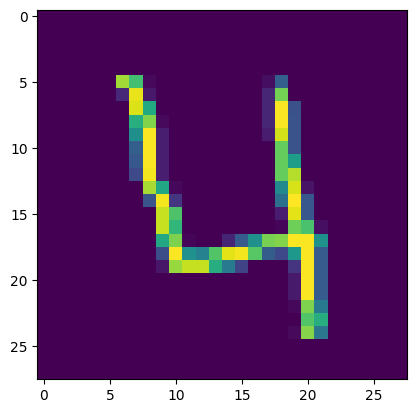

In [49]:
plt.imshow(df.iloc[3,1:].values.reshape(28,28))

In [50]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
X_train.shape

(33600, 784)

In [53]:
X_test.shape

(8400, 784)

In [54]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [55]:
accuracy_score(y_test, y_pred)

0.9648809523809524

# Using SKLearn:

In [56]:
scaler = StandardScaler()

In [57]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [58]:
pca = PCA(n_components=100)

In [59]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [60]:
X_train.shape

(33600, 784)

In [61]:
X_train_trf.shape

(33600, 100)

In [62]:
knn = KNeighborsClassifier()

In [63]:

knn.fit(X_train_trf, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](10,)","[0,1,2,...,7,8,9]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [64]:
y_pred = knn.predict(X_test_trf)

In [65]:
accuracy_score(y_test, y_pred)

0.9544047619047619

# Checking for best N_Components:
Running all the below cells in sequence is important.

In [66]:
df = pd.read_csv('D:/Important Files/Machine Learning/Datasets/MNIST.csv')

In [67]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [69]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [70]:
scores = []
for i in range(1, 785, 10):
    pca = PCA(n_components=i)
    X_train_trf = pca.fit_transform(X_train)
    X_test_trf = pca.transform(X_test)
    
    knn = KNeighborsClassifier()
    knn.fit(X_train_trf, y_train)
    y_pred = knn.predict(X_test_trf)
    
    scores.append(accuracy_score(y_test, y_pred))

best_n_components = scores.index(max(scores)) + 1
print(f"Best n_components: {best_n_components}, Accuracy: {max(scores):.4f}")

Best n_components: 9, Accuracy: 0.9551


# 2D Visualization:

In [71]:
pca = PCA(n_components=2)

In [72]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [73]:
X_train_trf

array([[-2.71863253, -0.48982409],
       [-0.67698015, -6.75362491],
       [-3.03323281,  6.50981624],
       ...,
       [ 2.14883643,  0.78079444],
       [ 1.05957006,  0.94767312],
       [17.70258446,  1.96188185]], shape=(33600, 2))

In [74]:
y_train_trf = y_train.astype(str)
fig = px.scatter(x=X_train_trf[:,0], y=X_train_trf[:,1], color=y_train_trf, color_discrete_sequence=px.colors.qualitative.G10)

fig.show()

# 3D Visualization:

In [75]:
pca = PCA(n_components=3)

In [76]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [77]:
X_train_trf

array([[-2.71863253, -0.48982409,  1.1354966 ],
       [-0.67698015, -6.75362491, -2.33590139],
       [-3.03323281,  6.50981624,  7.49182983],
       ...,
       [ 2.14883643,  0.78079444, -0.74738774],
       [ 1.05957006,  0.94767312,  3.94973114],
       [17.70258446,  1.96188185, -4.94352837]], shape=(33600, 3))

In [78]:
y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=X_train_trf[:,0], y=X_train_trf[:,1], z=X_train_trf[:,2], color=y_train_trf)
fig.update_layout(margin=dict(l=20, r=20, t=20, b=20))

fig.show()

### Explained Variance (Raw)

`explained_variance_` returns the actual variance (in the original units/scale of the data) 
captured by each principal component — these are the eigenvalues of the covariance matrix, 
one per component, ordered from highest to lowest.

These raw values are useful for comparing components to each other in absolute terms, but 
since they're in the original feature scale (not a percentage), they don't directly tell you 
what *proportion* of the dataset's total variance each component represents.

In [79]:
pca.explained_variance_

array([40.67111198, 29.17023401, 26.74459621])

In [80]:
pca.components_.shape

(3, 784)

### Explained Variance Ratio (as Percentage)

`explained_variance_ratio_` normalizes the raw variance values above into a proportion of the 
**total variance** in the dataset — each value tells you what percentage of the overall 
information each component individually captures. Multiplying by 100 just converts this from 
a decimal (e.g. 0.09) into a more readable percentage (e.g. 9%).

This is the metric typically used to decide how many components to keep — either by inspecting 
individual component contributions, or by taking a cumulative sum across components to find 
how many are needed to reach a target retained-variance threshold (e.g. 90% or 95%).

In [81]:
pca.explained_variance_ratio_*100

array([5.78519225, 4.14926968, 3.80423901])

In [82]:
pca = PCA(n_components=None)

X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [83]:
pca.explained_variance_.shape

(784,)

In [84]:
pca.components_.shape

(784, 784)

In [85]:
pca.explained_variance_ratio_[:50]

array([0.05785192, 0.0414927 , 0.03804239, 0.02966263, 0.02581562,
       0.0225498 , 0.01973068, 0.0177528 , 0.01568651, 0.01436063,
       0.01370255, 0.01227255, 0.01146912, 0.01123027, 0.01058529,
       0.01019931, 0.00957676, 0.00942709, 0.00912489, 0.0089017 ,
       0.0083994 , 0.00820063, 0.00785303, 0.0075674 , 0.00737261,
       0.00701885, 0.0069792 , 0.00671104, 0.00639845, 0.00630337,
       0.00615351, 0.00602389, 0.00583674, 0.00578548, 0.00572333,
       0.005464  , 0.00543207, 0.00528173, 0.00513382, 0.00494015,
       0.00487671, 0.00481979, 0.00468204, 0.00459342, 0.00457661,
       0.00449219, 0.00444682, 0.00441541, 0.00435112, 0.00432033])

### Cumulative Explained Variance

`np.cumsum()` computes the running total of the explained variance ratios — so the value at 
index `i` tells you the total proportion of variance captured by the **first `i+1` components 
combined**, not just one component in isolation.

This is the key metric for choosing `n_components`: instead of looking at how much variance 
each component adds individually, this shows how much information you retain as you keep 
adding components, up to any given point. Plotting this (or scanning the array) lets you find 
the smallest number of components that reach a target retained-variance threshold, like 90% or 
95%, which is a common way to pick `n_components` when the goal is faithful data compression 
rather than optimizing a downstream model directly.

In [86]:
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_90 = np.argmax(cum_var >= 0.90) + 1
n_95 = np.argmax(cum_var >= 0.95) + 1

print(f"Components for 90% variance: {n_90}")
print(f"Components for 95% variance: {n_95}")

Components for 90% variance: 223
Components for 95% variance: 315


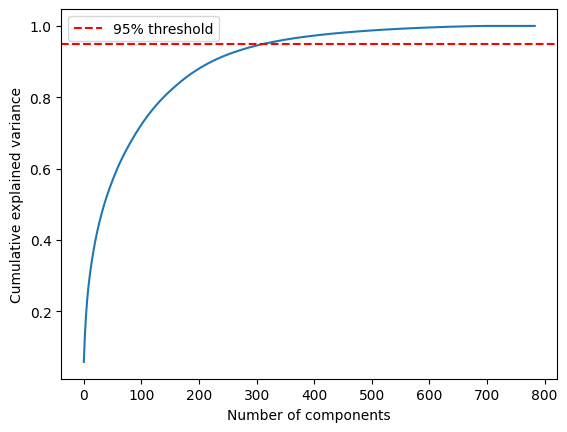

In [87]:
plt.plot(cum_var)
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.legend()
plt.show()

**Concretely, in this notebook:** the KNN search found n=9 optimal for classification 
accuracy (95.51%), while reaching 90% variance retention took 223 components and 95% took 
315 — a clear illustration that variance-maximizing components and classification-optimal 
components are not the same thing.

## How Much Variance Should the Components Capture, As a Whole?

There's no universal number — it depends on what you're using the components for:

| Use case | Typical target |
|---|---|
| General-purpose dimensionality reduction / preprocessing | 90–95% |
| Visualization only (2D/3D, like your later cells) | No variance target — you're intentionally sacrificing most information for interpretability |
| Noise reduction / denoising | Often lower, e.g. 80–90%, deliberately discarding low-variance components as "noise" |
| Downstream supervised model (like your KNN case) | Variance target is often irrelevant — tune `n_components` directly against validation accuracy instead, exactly like your search loop did |

---